In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [ ]:
rosenbrock = lambda v: 100*(v[1] - v[0]**2)**2 + (1 - v[0])**2
f = lambda v: v[0]**4 + 2*v[0]**2

x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)

In [ ]:
def plot_contour_with_path(path, func, x=x, y=y):
    X, Y = np.meshgrid(x, y)
    Z = func([X, Y])

    plt.contourf(X, Y, np.log1p(Z), levels=30, cmap='viridis')
    plt.colorbar(label='log(1 + f(x,y))')
    plt.plot(path[:, 0], path[:, 1], 'w.-', label='path')
    plt.plot(path[0, 0], path[0, 1], 'go', markersize=10, label='start')
    plt.plot(path[-1, 0], path[-1, 1], 'r*', markersize=15, label='end')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_1v_path(path, f, xs=x):
    plt.plot(xs, f([xs]), label='f(x)')
    plt.plot(path, f([path]), 'r.-', label='path')
    plt.plot(path[0],  f([path[0]]),  'go', markersize=10, label='start')
    plt.plot(path[-1], f([path[-1]]), 'r*', markersize=15, label='end')
    plt.legend(); plt.xlabel('x'); plt.ylabel('f(x)')
    plt.show()

In [5]:
def newton_method_id(x0, i, grad1, grad2):
    p = np.asarray(x0, dtype=float)
    path = [p.copy()]
    for _ in range(i-1):
        p = p - (grad1(p) / grad2(p))
        path.append(p.copy())
    return path

In [ ]:
grad1 = lambda x: 4*x**3 + 4*x
grad2 = lambda x: 12*x**2 + 4
path = newton_method_id(np.array(1.0), 3, grad1, grad2)
path = np.array(path)

print("path:", path)

path: [1.         0.5        0.14285714]


In [ ]:
def newton_method_bid(x0, i, gradf, H):
    Hinv  = np.linalg.inv(H)
    p = np.asarray(x0, dtype=float)
    path = [p.copy()]
    for _ in range(i-1):
        g = gradf(p[0], p[1])
        p = p - Hinv @ g
        path.append(p.copy())
    return np.array(path)

In [8]:
gradf = lambda x, y: np.array([2*x, 8*y])
H = np.array([[2, 0],[0, 8]])
x0 = np.array([3.0, 2.0])

path = newton_method_bid(x0, 3, gradf, H)
print("final:", path[-1]) 
print(path)

final: [0. 0.]
[[3. 2.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


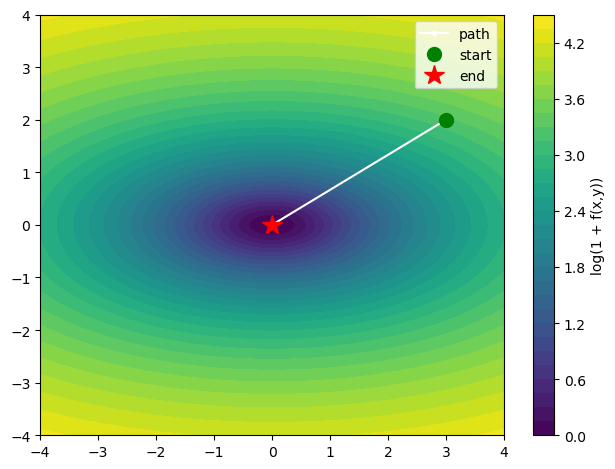

In [9]:
f = lambda v: v[0]**2 + 4*v[1]**2     # matches gradf/H above
plot_contour_with_path(path, f)

In [ ]:
def numerical_gradient(f, x, h=1e-5):
    x = np.asarray(x, dtype=float)
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x_fwd, x_bwd = x.copy(), x.copy()
        x_fwd[i] += h
        x_bwd[i] -= h
        grad[i] = (f(x_fwd) - f(x_bwd)) / (2*h)
    return grad


def numerical_hessian(f, x, h=1e-4):
    x = np.asarray(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            xpp, xpm, xmp, xmm = x.copy(), x.copy(), x.copy(), x.copy()
            xpp[i] += h; xpp[j] += h
            xpm[i] += h; xpm[j] -= h
            xmp[i] -= h; xmp[j] += h
            xmm[i] -= h; xmm[j] -= h
            H[i, j] = (f(xpp) - f(xpm) - f(xmp) + f(xmm)) / (4*h*h)
    return H


def taylor_series_approx(f, x0, x):
    """2nd-order Taylor approx of f around x0, evaluated at x.

    f(x) ~= f(x0) + g.d + 0.5 * d^T H d,   d = x - x0
    """
    x0 = np.asarray(x0, dtype=float)
    x = np.asarray(x, dtype=float)
    d = x - x0
    g = numerical_gradient(f, x0)
    H = numerical_hessian(f, x0)
    return f(x0) + g @ d + 0.5 * d @ H @ d


def newton_generic(f, x0, n_iters=50, tol=1e-8):
    """Newton using numerical gradient + Hessian. Works on any v-style f."""
    p = np.asarray(x0, dtype=float)
    path = [p.copy()]
    for _ in range(n_iters):
        g = numerical_gradient(f, p)
        if np.linalg.norm(g) < tol:
            break
        H = numerical_hessian(f, p)
        p = p - np.linalg.inv(H) @ g
        path.append(p.copy())
    return np.array(path)


rosenbrock = lambda v: 100*(v[1] - v[0]**2)**2 + (1 - v[0])**2          # min (1,1)
himmelblau = lambda v: (v[0]**2 + v[1] - 11)**2 + (v[0] + v[1]**2 - 7)**2  # 4 minima
booth      = lambda v: (v[0] + 2*v[1] - 7)**2 + (2*v[0] + v[1] - 5)**2  # min (1,3)
beale      = lambda v: ((1.5 - v[0] + v[0]*v[1])**2
                        + (2.25 - v[0] + v[0]*v[1]**2)**2
                        + (2.625 - v[0] + v[0]*v[1]**3)**2)             # min (3,0.5)

rosenbrock final: [0.99999998 0.99999996]


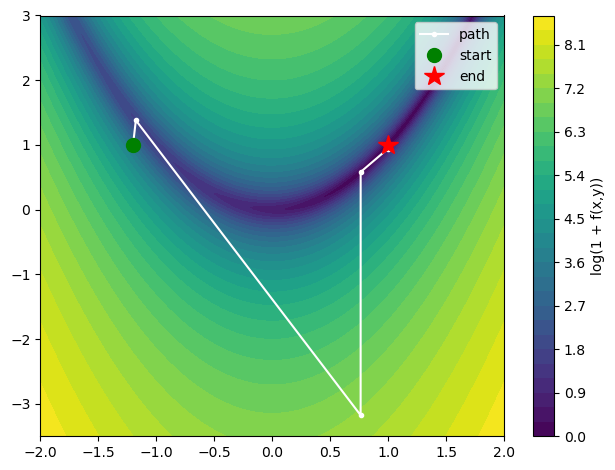

In [11]:
# Rosenbrock: start (-1.2, 1.0) -> (1,1)
path = newton_generic(rosenbrock, [-1.2, 1.0])
print("rosenbrock final:", path[-1])
plot_contour_with_path(path, rosenbrock, np.linspace(-2, 2, 200), np.linspace(-3.5, 3, 200))

himmelblau final: [3. 2.]


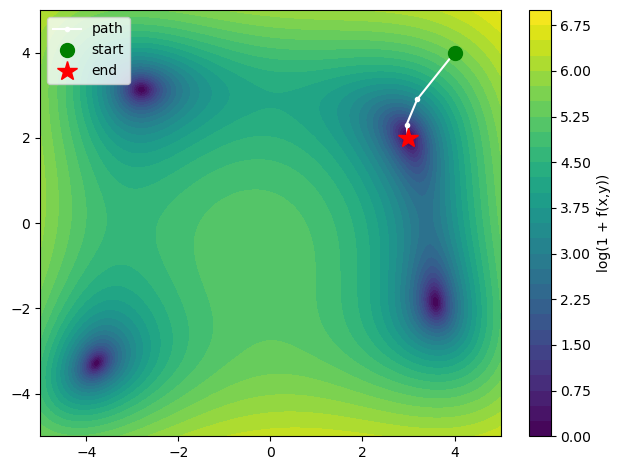

In [12]:
# Himmelblau: 4 minima. Newton -> nearest critical point.
# start (4,4) -> (3,2). Bad starts hit max/saddle (Newton solves grad=0, not min)
path = newton_generic(himmelblau, [4.0, 4.0])
print("himmelblau final:", path[-1])
plot_contour_with_path(path, himmelblau, np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))

booth final: [1. 3.]


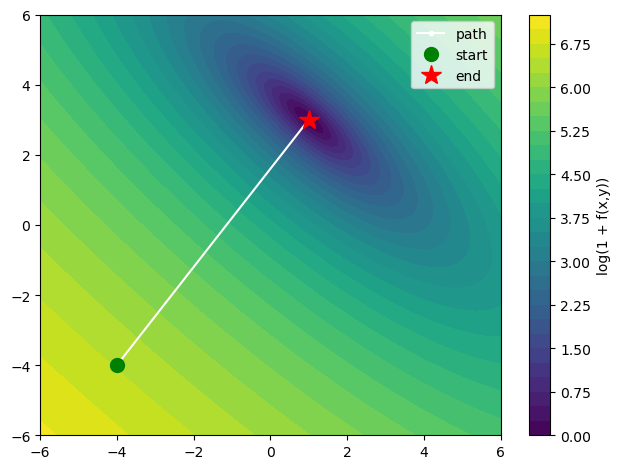

In [ ]:
path = newton_generic(booth, [-4.0, -4.0])
print("booth final:", path[-1])
plot_contour_with_path(path, booth, np.linspace(-6, 6, 200), np.linspace(-6, 6, 200))

beale final: [3.  0.5]


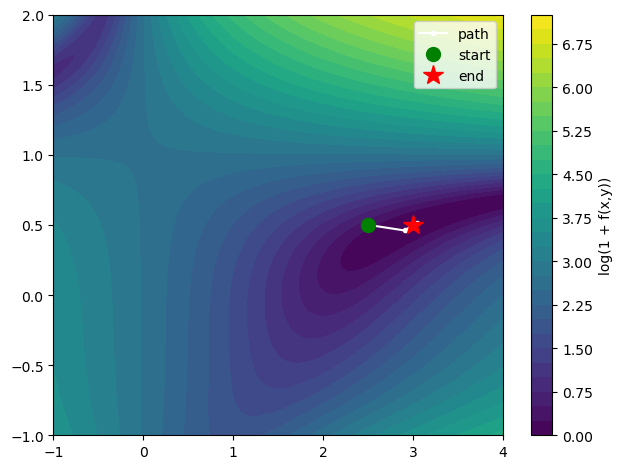

In [14]:
# Beale: min (3, 0.5). Newton sensitive; start near min
path = newton_generic(beale, [2.5, 0.5])
print("beale final:", path[-1])
plot_contour_with_path(path, beale, np.linspace(-1, 4, 200), np.linspace(-1, 2, 200))